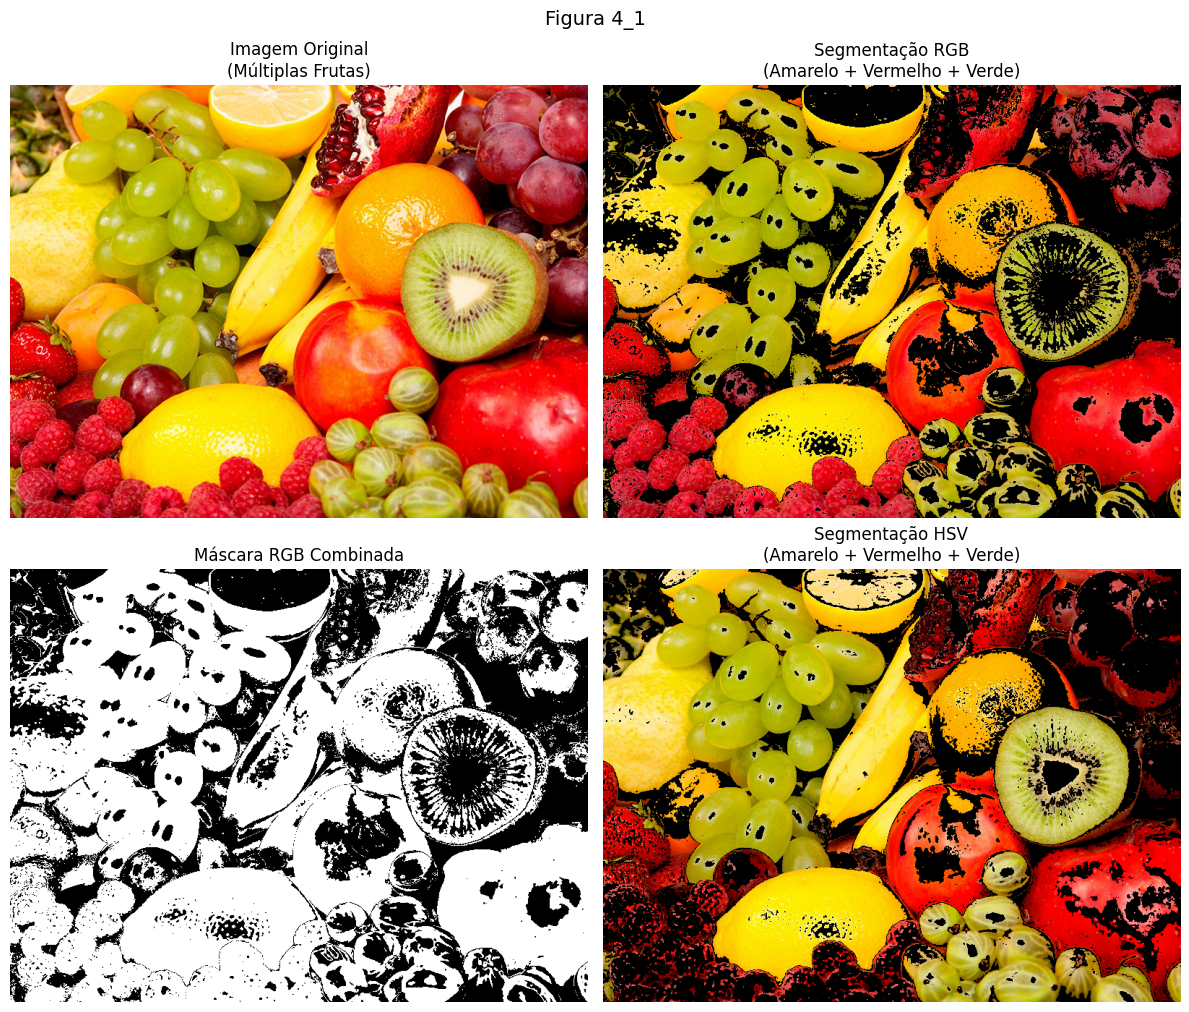

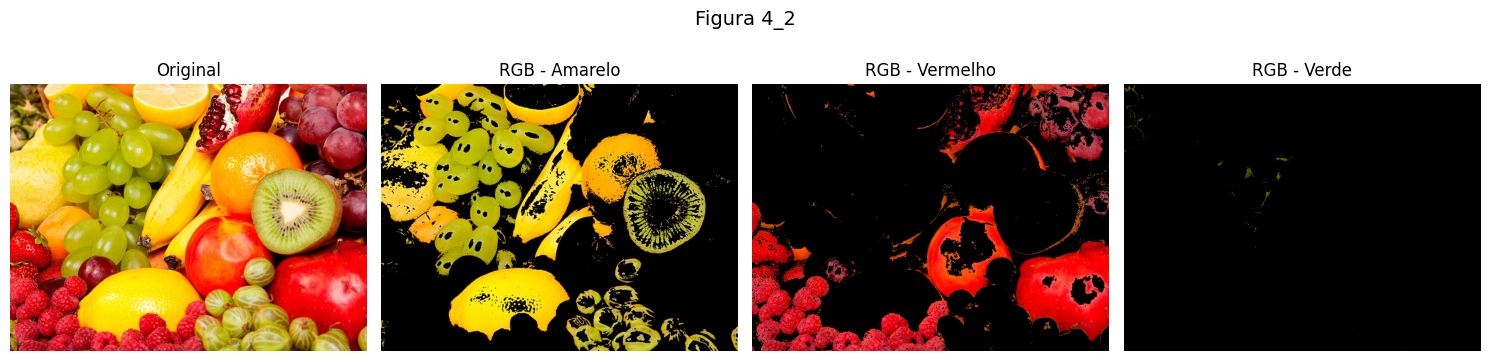

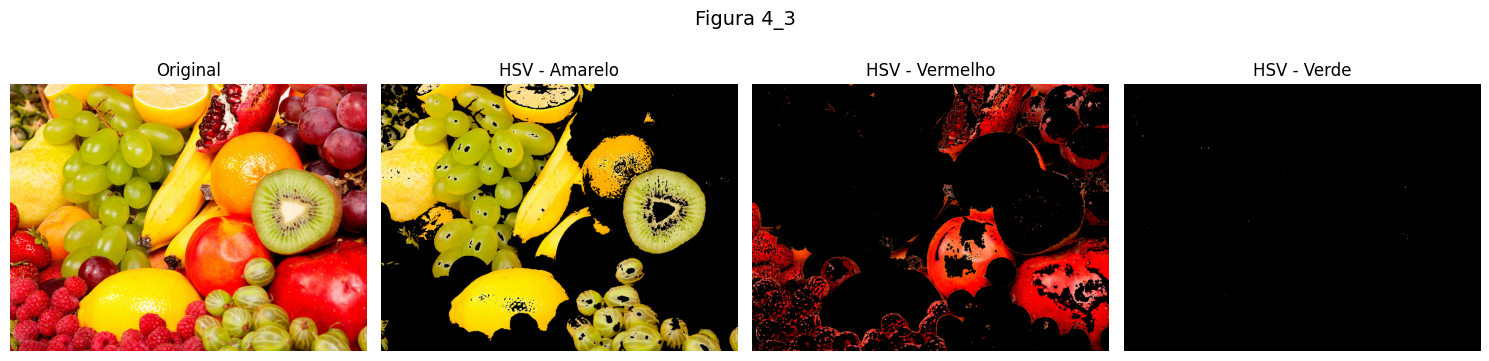

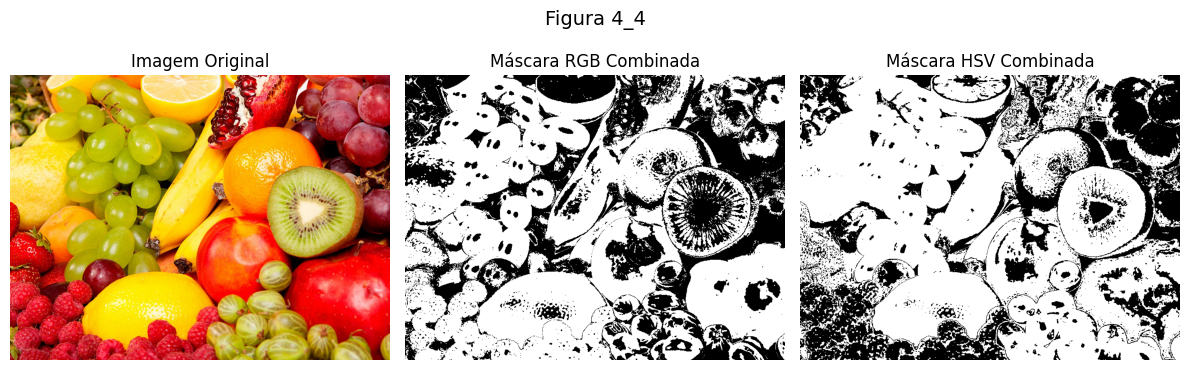

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def segment_rgb_multi(img_rgb, color_thresholds):
    h, w = img_rgb.shape[:2]
    mask_combined = np.zeros((h, w), dtype=np.uint8)
    masks = {}

    for color_name, thresholds in color_thresholds.items():
        R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

        mask = np.ones(R.shape, dtype=np.uint8) * 255
        for channel, (low, high) in thresholds.items():
            if channel == 'R':
                mask = cv2.bitwise_and(mask, cv2.inRange(R, low, high))
            elif channel == 'G':
                mask = cv2.bitwise_and(mask, cv2.inRange(G, low, high))
            elif channel == 'B':
                mask = cv2.bitwise_and(mask, cv2.inRange(B, low, high))

        masks[color_name] = mask
        mask_combined = cv2.bitwise_or(mask_combined, mask)

    return mask_combined, masks

def segment_hsv_multi(img_bgr, hsv_ranges):
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, w = img_hsv.shape[:2]
    mask_combined = np.zeros((h, w), dtype=np.uint8)
    masks = {}

    for color_name, (lower, upper) in hsv_ranges.items():
        mask = cv2.inRange(img_hsv, lower, upper)
        masks[color_name] = mask
        mask_combined = cv2.bitwise_or(mask_combined, mask)

    return mask_combined, masks

def apply_segmentation(img_rgb, mask):
    return cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

def multicolor_segmentation(img_path):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


    # THRESHOLDS PARA CADA COR
    rgb_thresholds = {
        'Amarelo': {'R': (150, 255), 'G': (150, 255), 'B': (0, 100)},
        'Vermelho': {'R': (150, 255), 'G': (0, 100), 'B': (0, 100)},
        'Verde': {'R': (0, 100), 'G': (80, 255), 'B': (0, 100)}
    }

    hsv_ranges = {
        'Amarelo': (np.array([20, 80, 100]), np.array([35, 255, 255])),
        'Vermelho': (np.array([0, 100, 50]), np.array([10, 255, 255])),
        'Verde': (np.array([35, 50, 50]), np.array([85, 255, 255]))
    }

    # SEGMENTAÇÃO RGB
    mask_rgb_combined, masks_rgb = segment_rgb_multi(img_rgb, rgb_thresholds)
    seg_rgb_combined = apply_segmentation(img_rgb, mask_rgb_combined)

    # Segmentação individual RGB para visualização
    seg_rgb_individual = {}
    for color_name, mask in masks_rgb.items():
        seg_rgb_individual[color_name] = apply_segmentation(img_rgb, mask)

    # SEGMENTAÇÃO HSV
    mask_hsv_combined, masks_hsv = segment_hsv_multi(img_bgr, hsv_ranges)
    seg_hsv_combined = apply_segmentation(img_rgb, mask_hsv_combined)

    # Segmentação individual HSV para visualização
    seg_hsv_individual = {}
    for color_name, mask in masks_hsv.items():
        seg_hsv_individual[color_name] = apply_segmentation(img_rgb, mask)

    # VISUALIZAÇÃO
    # Figura 1: Comparação geral RGB vs HSV
    fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))

    axes1[0, 0].imshow(img_rgb)
    axes1[0, 0].set_title('Imagem Original\n(Múltiplas Frutas)')
    axes1[0, 0].axis('off')

    axes1[0, 1].imshow(seg_rgb_combined)
    axes1[0, 1].set_title('Segmentação RGB\n(Amarelo + Vermelho + Verde)')
    axes1[0, 1].axis('off')

    axes1[1, 0].imshow(mask_rgb_combined, cmap='gray')
    axes1[1, 0].set_title('Máscara RGB Combinada')
    axes1[1, 0].axis('off')

    axes1[1, 1].imshow(seg_hsv_combined)
    axes1[1, 1].set_title('Segmentação HSV\n(Amarelo + Vermelho + Verde)')
    axes1[1, 1].axis('off')

    plt.tight_layout()
    plt.suptitle('Figura 4_1', fontsize=14, y=1.02)
    plt.show()

    # Figura 2: Segmentação por cor individual - RGB
    fig2, axes2 = plt.subplots(1, 4, figsize=(15, 4))

    axes2[0].imshow(img_rgb)
    axes2[0].set_title('Original')
    axes2[0].axis('off')

    axes2[1].imshow(seg_rgb_individual.get('Amarelo', np.zeros_like(img_rgb)))
    axes2[1].set_title('RGB - Amarelo')
    axes2[1].axis('off')

    axes2[2].imshow(seg_rgb_individual.get('Vermelho', np.zeros_like(img_rgb)))
    axes2[2].set_title('RGB - Vermelho')
    axes2[2].axis('off')

    axes2[3].imshow(seg_rgb_individual.get('Verde', np.zeros_like(img_rgb)))
    axes2[3].set_title('RGB - Verde')
    axes2[3].axis('off')

    plt.tight_layout()
    plt.suptitle('Figura 4_2', fontsize=14, y=1.02)
    plt.show()

    # Figura 3: Segmentação por cor individual - HSV
    fig3, axes3 = plt.subplots(1, 4, figsize=(15, 4))

    axes3[0].imshow(img_rgb)
    axes3[0].set_title('Original')
    axes3[0].axis('off')

    axes3[1].imshow(seg_hsv_individual.get('Amarelo', np.zeros_like(img_rgb)))
    axes3[1].set_title('HSV - Amarelo')
    axes3[1].axis('off')

    axes3[2].imshow(seg_hsv_individual.get('Vermelho', np.zeros_like(img_rgb)))
    axes3[2].set_title('HSV - Vermelho')
    axes3[2].axis('off')

    axes3[3].imshow(seg_hsv_individual.get('Verde', np.zeros_like(img_rgb)))
    axes3[3].set_title('HSV - Verde')
    axes3[3].axis('off')

    plt.tight_layout()
    plt.suptitle('Figura 4_3', fontsize=14, y=1.02)
    plt.show()

    # Figura 4: Comparação lado a lado das máscaras combinadas
    fig4, axes4 = plt.subplots(1, 3, figsize=(12, 4))

    axes4[0].imshow(img_rgb)
    axes4[0].set_title('Imagem Original')
    axes4[0].axis('off')

    axes4[1].imshow(mask_rgb_combined, cmap='gray')
    axes4[1].set_title('Máscara RGB Combinada')
    axes4[1].axis('off')

    axes4[2].imshow(mask_hsv_combined, cmap='gray')
    axes4[2].set_title('Máscara HSV Combinada')
    axes4[2].axis('off')

    plt.tight_layout()
    plt.suptitle('Figura 4_4', fontsize=14, y=1.02)
    plt.show()

# Executar segmentação múltipla
multicolor_segmentation('img/frutas.jpg')